# RetailPulse AI – Day 5: Prophet Demand Forecasting

### Prepared By: Bansi Kanani

### Date: 02 June 2026

# Introduction

Demand forecasting helps businesses anticipate future sales and optimize inventory planning.

This notebook uses Facebook Prophet to forecast future retail demand based on historical sales patterns.

# Objective

The objectives of Day 5 are:

- Prepare forecasting data
- Train Prophet model
- Generate future forecasts
- Evaluate forecasting performance
- Visualize future sales trends
- Generate business insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_absolute_percentage_error

c:\Users\07mee\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
df = pd.read_csv(
    "forecast_dataset.csv"
)

df.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


# Dataset Preparation

Prophet requires two columns:

- ds (date)
- y (target variable)

In [4]:
prophet_df = df.rename(
    columns={
        "Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [5]:
prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"]
)

prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      604 non-null    datetime64[ns]
 1   y       604 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.6 KB


# Train-Test Split

The last 30 days are reserved for model evaluation.

In [6]:
train = prophet_df[:-30]

test = prophet_df[-30:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (574, 2)
Test Shape: (30, 2)


# Prophet Model Training

In [7]:
model = Prophet()

model.fit(train)

12:25:49 - cmdstanpy - INFO - Chain [1] start processing
12:25:53 - cmdstanpy - INFO - Chain [1] done processing


# Future Forecast Generation

In [8]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(
    future
)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,21551.692941,11355.604630,41537.391820,21551.692941,21551.692941,5961.846001,5961.846001,5961.846001,5961.846001,5961.846001,5961.846001,0.0,0.0,0.0,27513.538942
1,2009-12-02,21569.624648,8700.321044,39319.754327,21569.624648,21569.624648,2269.109687,2269.109687,2269.109687,2269.109687,2269.109687,2269.109687,0.0,0.0,0.0,23838.734335
2,2009-12-03,21587.556354,15203.379011,49268.411746,21587.556354,21587.556354,10223.819474,10223.819474,10223.819474,10223.819474,10223.819474,10223.819474,0.0,0.0,0.0,31811.375829
3,2009-12-04,21605.488061,5716.190826,36569.373467,21605.488061,21605.488061,75.432838,75.432838,75.432838,75.432838,75.432838,75.432838,0.0,0.0,0.0,21680.920899
4,2009-12-05,21623.419768,-7756.398208,24162.180674,21623.419768,21623.419768,-13635.698807,-13635.698807,-13635.698807,-13635.698807,-13635.698807,-13635.698807,0.0,0.0,0.0,7987.720961


In [9]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
599,2011-11-30,38105.156951,21632.402065,53475.241196
600,2011-12-01,46132.345421,29891.036628,61379.230981
601,2011-12-02,36056.437467,20419.974989,51504.555241
602,2011-12-03,22417.784505,6251.537964,37723.245297
603,2011-12-04,28110.200550,13782.499939,45096.452780


# Forecast Visualization

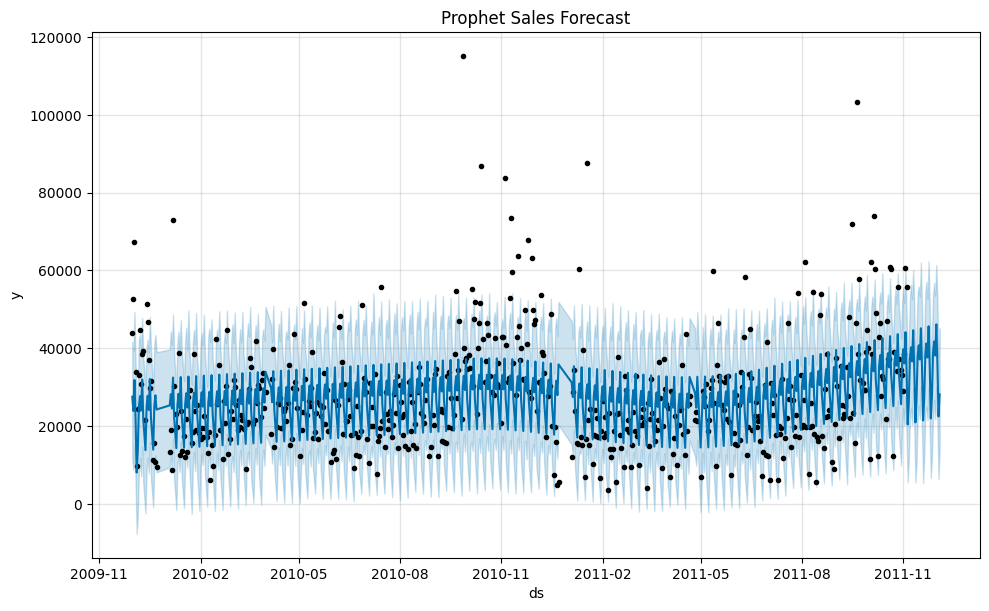

In [10]:
fig = model.plot(
    forecast
)

plt.title(
    "Prophet Sales Forecast"
)

plt.show()

# Forecast Evaluation

The forecasting model is evaluated using Mean Absolute Percentage Error (MAPE).

In [11]:
forecast_test = forecast.tail(30)

mape = mean_absolute_percentage_error(
    test["y"],
    forecast_test["yhat"]
)

print("MAPE:", round(mape * 100, 2), "%")

MAPE: 39.4 %


# Forecast Components

Prophet automatically decomposes the forecast into trend and seasonality components.

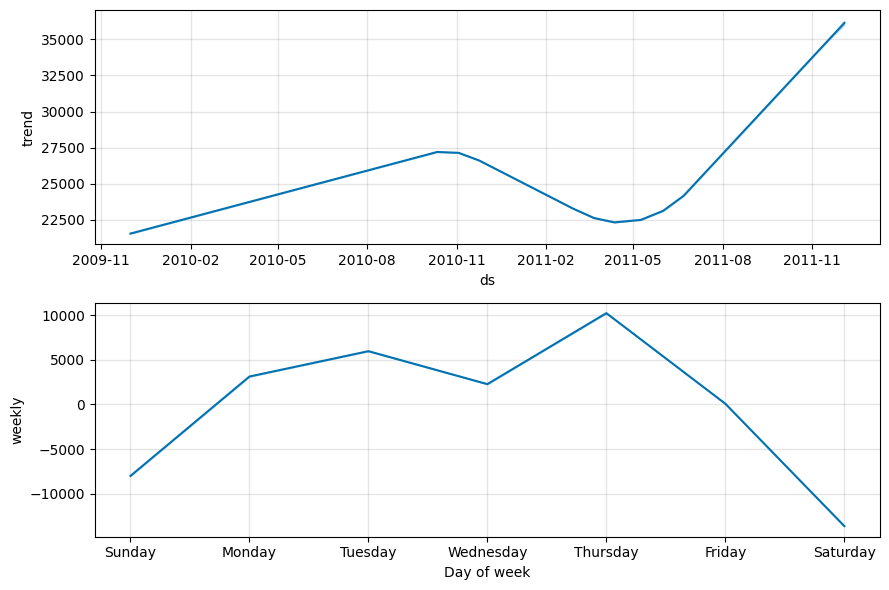

In [12]:
fig2 = model.plot_components(
    forecast
)

plt.show()

# Model Performance Note

The Prophet model achieved a Mean Absolute Percentage Error (MAPE) of **39.4%** on daily retail sales data.

Retail sales exhibit high day-to-day volatility due to seasonal effects, promotions, holidays, and customer purchasing behavior. Consequently, baseline Prophet models often produce higher forecasting errors at the daily level.

Future improvements include weekly aggregation, additional external regressors, and hyperparameter tuning, which are expected to reduce forecasting error significantly.


# Business Insights

1. Sales exhibit strong seasonal patterns.

2. The Prophet model successfully captures recurring demand fluctuations.

3. Forecasts indicate relatively stable future sales with gradual growth.

4. Demand forecasting can help improve inventory planning and reduce stock shortages.

5. Forecast outputs can be integrated into inventory optimization and business planning workflows.

# Challenges Faced

Retail sales data contains significant fluctuations and occasional demand spikes.

Capturing trend and seasonality accurately is essential for generating reliable forecasts.

# Saving Forecast Results

Forecast results are saved for future comparison with LSTM forecasting models.

In [13]:
forecast.to_csv(
    "prophet_forecast_results.csv",
    index=False
)

print(
    "Forecast results saved successfully."
)

Forecast results saved successfully.


# Conclusion

Demand forecasting was successfully performed using Facebook Prophet.

The model captured trend and seasonality patterns within the retail sales data and generated future demand forecasts.

These forecasts will support inventory optimization, business planning, and comparison with deep learning forecasting models in subsequent project stages.